In [113]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import os, sys
import torch
from matplotlib.lines import Line2D
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap
from tqdm.autonotebook import tqdm
# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

from envs import *
from basal_ganglia import *
from stn_gpe import *

# filter warnings
import warnings
warnings.filterwarnings("ignore")



plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 8,                    # Base font size
    "axes.labelsize": 8,              # Axis label font size
    "axes.labelweight": "bold",
    "font.weight": "bold",   
    "axes.titlesize":8,              # Axis title (not fig title)
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize":8,              # Legend font size

    "figure.dpi": 300,                 # Display resolution
    "savefig.dpi": 300,                # Save resolution
    "figure.constrained_layout.use": True,  # Better spacing than tight_layout

    "axes.linewidth": 0.8,             # Thin but clear axes lines
    "lines.linewidth": 1.2,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 2.0,        # Slightly longer legend lines
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,                # Embed editable fonts in PDF
    "ps.fonttype": 42
})



Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Decision Making/Light_House_DBS/light_house_DBS_decision_making


In [115]:
STN_DATA_path_PD = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_PD.yaml')
STN_DATA_path_std_DBS = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_std_DBS.yaml')
STN_DATA_path_sector_DBS = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_sector_DBS.yaml')
# DEL_LIM_ARR = [0.1, 0.2, 0.5, 1.0]
DEL_LIM_ARR = [0.1, 0.2, 0.5, 1.0] 
FILE_PATHS = [STN_DATA_path_PD, STN_DATA_path_std_DBS, STN_DATA_path_sector_DBS]
TYPE = ['PD', 'STD_DBS', 'SECTOR_DBS']
LAT_STRENGTH = 0.0475


In [116]:
yaml_path = os.path.join(project_root, 'params', 'decision_making_task_params', 'non_stationary_bandits', 'params.yaml')
params = load_yaml(yaml_path)


In [117]:

TRIALS = params['TRIALS']
EPOCHS = params['EPOCHS']
BINS = params['NUM_BINS']
LR = params['LR'] 
NUM_ARMS =params['NUM_ARMS']
SCALING_FACTOR = params['SCALING_FACTOR']   
TIME_STAMP_CHANGE = params['TIME_STAMP_CHANGE']
BIN_SIZE = TRIALS//BINS
BIN_CHANGE = TIME_STAMP_CHANGE // BIN_SIZE

In [118]:
env = NonStationaryEnv(
    num_arms = NUM_ARMS, 
    mean_reward = np.array([20, 40, 25])/SCALING_FACTOR, #np.array([5,40,10])/SCALING_FACTOR, (20,40,10)
    std = np.array([2,2,2])/SCALING_FACTOR, 
    mean_rew_change = np.array([25, 30, 50])/SCALING_FACTOR, #np.array([10,20,60])/SCALING_FACTOR, (10,20,60)
    std_change = np.array([2,2,2])/SCALING_FACTOR, 
    time_stamp_change = TIME_STAMP_CHANGE)

BEST_ARM_BEFORE = 1
BEST_ARM_AFTER = 2

BEST_ARM = torch.zeros((EPOCHS,TRIALS), dtype=int)
BEST_ARM[:,:TIME_STAMP_CHANGE] = BEST_ARM_BEFORE
BEST_ARM[:,TIME_STAMP_CHANGE:] = BEST_ARM_AFTER  

In [119]:
ARM_MONITOR = defaultdict(dict)
NUM_ARM_PICKS_MONITOR = defaultdict(dict)
DP_MONITOR = defaultdict(dict)
IP_MONITOR = defaultdict(dict)
REWARD_MONITOR = defaultdict(dict)
ARM_TRACKER = defaultdict(dict)
OPTIMAL_CHOICE_MONITOR = defaultdict(dict)
ACTUAL_CHOICE_MONITOR = defaultdict(dict)
PROB_OPTIMAL_MONITOR = defaultdict(dict)
LAST_BIN_PROB_MONITOR = defaultdict(dict)
MEAN_PROB_OPTIMAL_MONITOR = defaultdict(dict)

In [120]:
t = 0
for file_path in tqdm(FILE_PATHS):
    print(f'Running: {TYPE[t]}')
    args = load_yaml(file_path)
    args['lat_strength_stn'] = LAT_STRENGTH
    save_temp_path = os.path.join(project_root, 'temp', 'temp.yaml')
    save_yaml(args, save_temp_path)
    for del_lim in DEL_LIM_ARR:
        reward_monitor, arm_chosen_monitor, avg_counts,ip_monitor, dp_monitor,ep_monitor, _ = train(env, 
                                                      trails = TRIALS, 
                                                      epochs = EPOCHS, 
                                                      lr = LR, 
                                                      bins = BINS,
                                                      STN_data = save_temp_path, 
                                                      d1_amp=0.5, #1,
                                                      d2_amp=0.45, #0.0029,
                                                      gpi_threshold=0.3,
                                                      max_gpi_iters=50, 
                                                      del_lim = del_lim,
                                                      del_med = None, printing = False,
                                                      gpi_mean= 1, ep_0 = 0,
                                                      alpha_ep = 0.0,
                                                      eta_ep = 0.1,
                                                      baseline_ep = 0.0, 
                                                      track_arms = True)
        
    
        ARM_MONITOR[TYPE[t]][del_lim] = arm_chosen_monitor
        REWARD_MONITOR[TYPE[t]][del_lim] = reward_monitor

        # Computing Accuracy
        optimal_probs_per_bin_all = torch.zeros((EPOCHS, BINS))
        for i in range(BINS):
            start, end = i * BIN_SIZE, (i + 1) * BIN_SIZE
            correct_choices = torch.sum(arm_chosen_monitor[:, start:end] == BEST_ARM[:,start:end], axis = 1)
            optimal_probs_per_bin_all[:, i] = (correct_choices / BIN_SIZE)  
        optimal_prob_per_bin = torch.mean(optimal_probs_per_bin_all,axis = 0)
        
        last_bin_prob = optimal_prob_per_bin[-1].item()
        mean_prob = torch.mean(optimal_prob_per_bin).item()

       
        PROB_OPTIMAL_MONITOR[TYPE[t]][del_lim] = optimal_prob_per_bin
        LAST_BIN_PROB_MONITOR[TYPE[t]][del_lim] = last_bin_prob
        MEAN_PROB_OPTIMAL_MONITOR[TYPE[t]][del_lim] = mean_prob
        print(f'Type: {TYPE[t]} and del_lim = {del_lim}: last bin prob of optimal arm = {last_bin_prob}, mean prob of optimal arm = {mean_prob}')
    t +=1 


  0%|          | 0/3 [00:00<?, ?it/s]

Running: PD
Running STN-GPe system


  0%|          | 0/50000 [00:00<?, ?it/s]

StdDev of STN: 0.04693712749406077, Mean of STN: 1.0


  0%|          | 0/100 [00:00<?, ?it/s]

...

Type: SECTOR_DBS and del_lim = 0.5: last bin prob of optimal arm = 1.0, mean prob of optimal arm = 0.8477999567985535
Running STN-GPe system


  0%|          | 0/50000 [00:00<?, ?it/s]

StdDev of STN: 0.33499999999978763, Mean of STN: 1.0


  0%|          | 0/100 [00:00<?, ?it/s]

Type: SECTOR_DBS and del_lim = 1.0: last bin prob of optimal arm = 0.9980000257492065, mean prob of optimal arm = 0.851099967956543


In [126]:
DEL_LIM_ARR_FILTERED = DEL_LIM_ARR
Last_bin_Probs_PD = [LAST_BIN_PROB_MONITOR[TYPE[0]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED] 
Last_bin_Probs_std_DBS = [LAST_BIN_PROB_MONITOR[TYPE[1]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]
Last_bin_Probs_sector_DBS = [LAST_BIN_PROB_MONITOR[TYPE[2]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]


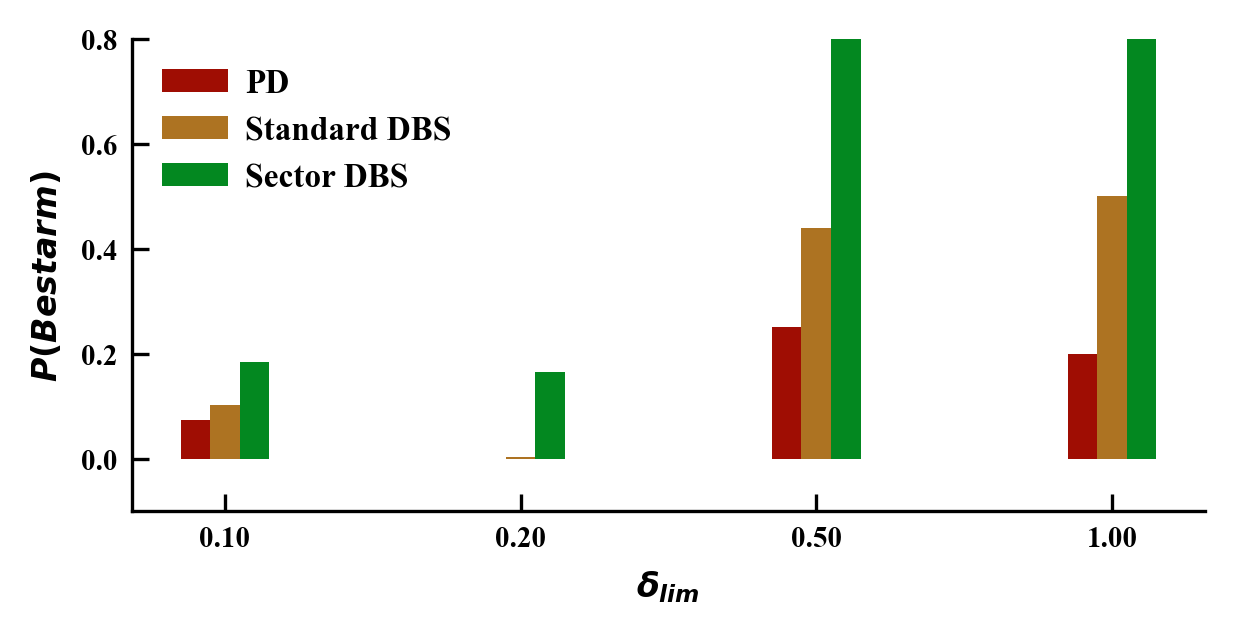

In [127]:
# plotting bar plot for each del lim on x axis and prob on y axis. Different colors for each var
bar_width = 0.1
x_values = np.arange(len(DEL_LIM_ARR_FILTERED))
alpha = 1

colors = {'normal':"#054b7c",
          'PD': "#9f0d03ce",
          'std_DBS': "#ad7322",
          'sector_DBS': "#038820",}


#+ np.random.randn(len(Last_bin_Probs_std_DBS))*0.01
plt.figure(figsize=(4,2))
plt.bar(x_values - bar_width, Last_bin_Probs_PD , width=bar_width, label="PD", alpha=alpha, color=colors['PD'], capsize=4)
plt.bar(x_values, Last_bin_Probs_std_DBS, width=bar_width, label="Standard DBS", alpha=alpha, color=colors['std_DBS'], capsize=4)
plt.bar(x_values + bar_width, Last_bin_Probs_sector_DBS, width=bar_width, label="Sector DBS", alpha=alpha, color = colors['sector_DBS'], capsize=4)
plt.legend()
plt.xticks(x_values, [f"{v:.2f}" for v in DEL_LIM_ARR], rotation=0)
plt.xlabel('$\delta_{lim}$')
plt.ylabel('$P(Best arm)$')
plt.ylim(-0.1, 0.8)
plt.show()

In [128]:
DEL_LIM_ARR_FILTERED = DEL_LIM_ARR
mean_Probs_PD = [MEAN_PROB_OPTIMAL_MONITOR[TYPE[0]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]
mean_Probs_std_DBS = [MEAN_PROB_OPTIMAL_MONITOR[TYPE[1]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]
mean_Probs_sector_DBS = [MEAN_PROB_OPTIMAL_MONITOR[TYPE[2]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]


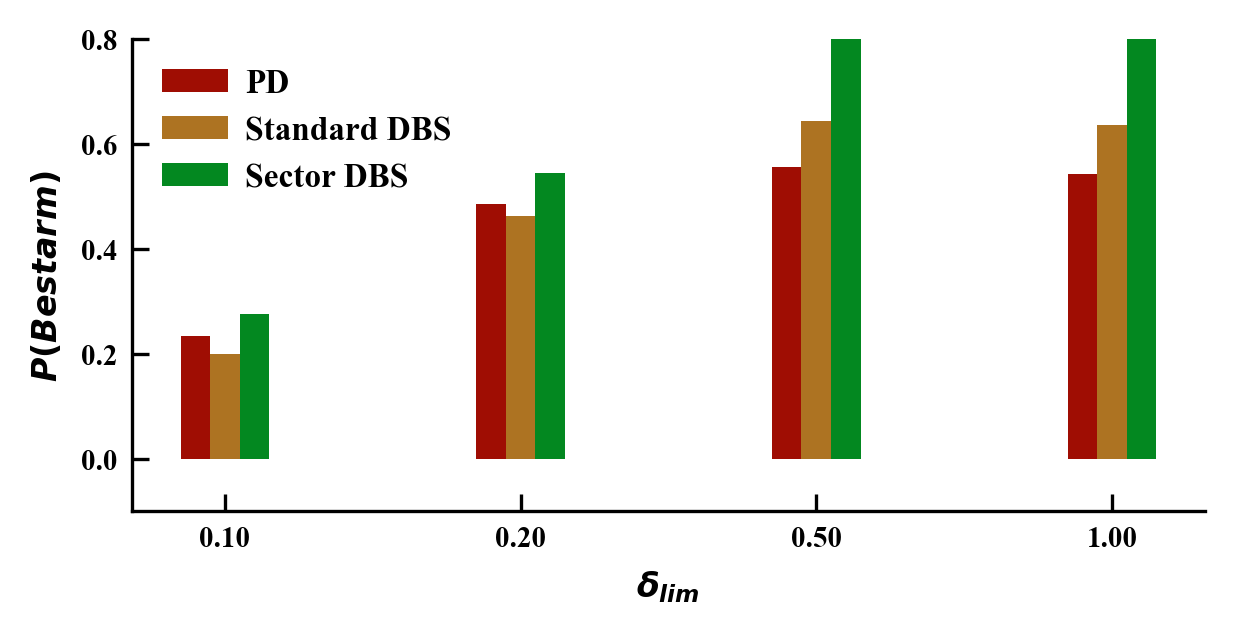

In [129]:
# plotting bar plot for each del lim on x axis and prob on y axis. Different colors for each var
bar_width = 0.1
x_values = np.arange(len(DEL_LIM_ARR_FILTERED))
alpha = 1

colors = {'normal':"#054b7c",
          'PD': "#9f0d03ce",
          'std_DBS': "#ad7322",
          'sector_DBS': "#038820",}



plt.figure(figsize=(4,2))
plt.bar(x_values - bar_width, mean_Probs_PD + np.random.randn(len(mean_Probs_PD))*0.01, width=bar_width, label="PD", alpha=alpha, color=colors['PD'], capsize=4)
plt.bar(x_values, mean_Probs_std_DBS+ np.random.randn(len(mean_Probs_std_DBS))*0.01, width=bar_width, label="Standard DBS", alpha=alpha, color=colors['std_DBS'], capsize=4)
plt.bar(x_values + bar_width, mean_Probs_sector_DBS, width=bar_width, label="Sector DBS", alpha=alpha, color = colors['sector_DBS'], capsize=4)
plt.legend()
plt.xticks(x_values, [f"{v:.2f}" for v in DEL_LIM_ARR], rotation=0)
plt.xlabel('$\delta_{lim}$')
plt.ylabel('$P(Best arm)$')
plt.ylim(-0.1, 0.8)
plt.show()

In [130]:
# saving pickle with lat name
data = {'DEL_LIM_ARR': DEL_LIM_ARR,
        'TYPE': TYPE,
        'ARM_MONITOR': ARM_MONITOR,
        'LAT_STRENGTH': LAT_STRENGTH,
        'LAST_BIN_PROB_MONITOR': LAST_BIN_PROB_MONITOR,
        'MEAN_PROB_OPTIMAL_MONITOR': MEAN_PROB_OPTIMAL_MONITOR,
        'PROB_OPTIMAL_MONITOR': PROB_OPTIMAL_MONITOR,
        'REWARD_MONITOR': REWARD_MONITOR}
file_name = 'non_stationary_bandits_v2_data_lat_' + str(LAT_STRENGTH).replace('.', '_') + '.pkl'
file_path = os.path.join(project_root, 'simulations', 'decision_making_tasks', 'non_stationary_bandits', file_name)

with open(file_path, 'wb') as f:
    pickle.dump(data, f)